# Manejo de datos raster en Python 
**Curso:** Análisis Geoespacial, Departamento de Geociencias y Medio Ambiente, Universidad Nacional de Colombia - sede Medellín

**Profesor:** Edier Aristizábal (evaristizabalg@unal.edu.co)

Un raster es una malla regular de celdas donde cada celda guarda un valor: elevación, pendiente, cohesión, reflectancia, precipitación. A diferencia de los datos vectoriales, aquí la geometría no se almacena explícitamente: se deduce de la posición de la celda dentro de la malla y de unos pocos parámetros de georreferenciación.

Este notebook parte del formato más elemental posible —texto plano— para hacer visible qué información necesita un raster para ser un dato *espacial* y no solo una matriz de números. Se trabaja con dos archivos reales de laderas del valle de Aburrá: un modelo digital de elevación (`dtm.asc`) y las unidades geológicas (`geologia.txt`). Con el modelo de elevación se calcula el sombreado del relieve paso a paso, y se termina con un GeoTIFF descargado desde internet.

## 1. Preparar el entorno

Se trabaja con `numpy` para la malla de valores, `pandas` para los resúmenes tabulares, `matplotlib` para las figuras y `pathlib` para las rutas de archivo. `rasterio` aparece más adelante, cuando se necesite leer el archivo como dato georreferenciado.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy      :", np.__version__)
print("matplotlib :", plt.matplotlib.__version__)

numpy      : 2.4.4
matplotlib : 3.11.0


Los archivos de entrada están en carpetas del computador, por fuera del repositorio del curso. **Estas rutas deben ajustarse a la ubicación de los datos en cada máquina.** Los resultados se escribirán en una carpeta de salida dentro del directorio de datos del curso.

In [2]:
DIR_ASCII = Path(r"C:\Users\edier\Documents\PERSONAL\POSGRADOS\PhD_Unal"
                 r"\SIG\MAPAS_edier\ASCII_edier")
DIR_TXT = Path(r"C:\Users\edier\Documents\CATEDRA\MACHINE LEARNING\datos\raster")

ruta_dtm = DIR_ASCII / "dtm.asc"            # modelo digital de elevación
ruta_geologia = DIR_TXT / "geologia.txt"    # unidades geológicas

DIR_SALIDA = Path("../data/salidas")
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

for ruta in (ruta_dtm, ruta_geologia):
    print(f"{ruta.name:<15} existe: {ruta.exists()}   "
          f"{ruta.stat().st_size / 1024**2:.2f} MB")

print("\nSalidas en:", DIR_SALIDA.resolve())

dtm.asc         existe: True   1.37 MB
geologia.txt    existe: True   3.90 MB

Salidas en: C:\Users\edier\Documents\CATEDRA\ANALISISGEOESPACIAL\AnalisisGeoespacial\Notebooks\data\salidas


## 2. Un ASCII Grid es un archivo de texto

`dtm.asc` es el modelo digital de elevación. Antes de usar cualquier biblioteca geoespacial conviene abrirlo como lo que es: texto plano. Se puede inspeccionar con `open`, con un editor o con el Bloc de notas.

In [ ]:
with open("C:/Users/edier/Documents/CATEDRA/MACHINE LEARNING/datos/raster/dtm.asc") as f:
    lines = f.readlines()

ncols         435
nrows         456
xllcorner     891236.30040912
yllcorner     1168994.6457458
cellsize      10
NODATA_value  -9999
-9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999
-9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999 -9999


Las primeras seis líneas son la **cabecera**, y las siguientes son los valores de las celdas separados por espacios. Esa cabecera es lo que convierte un montón de números en un dato espacial:

| Campo | Significado |
|---|---|
| `ncols` | número de columnas |
| `nrows` | número de filas |
| `xllcorner` | coordenada X de la esquina inferior izquierda de la malla |
| `yllcorner` | coordenada Y de la esquina inferior izquierda de la malla |
| `cellsize` | tamaño de celda (las celdas son cuadradas) |
| `NODATA_value` | valor que marca las celdas sin dato |

Algunos archivos usan `xllcenter` / `yllcenter` en lugar de `xllcorner` / `yllcorner`: la diferencia es si la coordenada se refiere a la esquina o al centro de la celda inferior izquierda, es decir, medio tamaño de celda.

Hay dos cosas que la cabecera **no** dice y conviene tener presentes desde ahora:

- En qué sistema de referencia están esas coordenadas. El ASCII Grid no guarda el CRS; se acompaña de un archivo `.prj` con el mismo nombre base, que aquí no existe.
- El orden de las filas está fijado por convención: **la primera fila de datos es la más al norte**. Es un detalle que causa errores con frecuencia, porque un mapa invertido verticalmente no siempre salta a la vista.

## 3. Leer el ASCII Grid con numpy

Si solo interesan los números, `np.loadtxt` con `skiprows=6` salta la cabecera de una vez. Pero entonces se obtiene exactamente eso: una matriz sin origen, sin tamaño de celda, sin CRS y sin saber qué valor significa "sin dato". Es lo que quedaría si alguien guardara el raster con un `np.savetxt` sin más.

In [6]:
solo_numeros = np.loadtxt(ruta_dtm, skiprows=6)

print("Forma:", solo_numeros.shape)
print("¿Los valores son los mismos?", np.array_equal(dtm_np, solo_numeros))
print("\nPero este arreglo ya no sabe dónde está en el mundo:")
print("primera fila, primeras columnas ->", solo_numeros[0, :6])

Forma: (456, 435)
¿Los valores son los mismos? True

Pero este arreglo ya no sabe dónde está en el mundo:
primera fila, primeras columnas -> [-9999. -9999. -9999. -9999. -9999. -9999.]


Con la cabecera, en cambio, se reconstruye la extensión geográfica del raster, es decir, las coordenadas de sus cuatro bordes.

In [7]:
izquierda = encabezado["xllcorner"]
abajo = encabezado["yllcorner"]
derecha = izquierda + encabezado["ncols"] * encabezado["cellsize"]
arriba = abajo + encabezado["nrows"] * encabezado["cellsize"]

print(f"X: de {izquierda:.1f} a {derecha:.1f} m")
print(f"Y: de {abajo:.1f} a {arriba:.1f} m")
print(f"La malla cubre {derecha - izquierda:.0f} m x {arriba - abajo:.0f} m")
print(f"Total de celdas: {encabezado['ncols'] * encabezado['nrows']:,}")

X: de 891236.3 a 895586.3 m
Y: de 1168994.6 a 1173554.6 m
La malla cubre 4350 m x 4560 m
Total de celdas: 198,360


## 4. Leer el ASCII Grid con rasterio

`rasterio` reconoce el formato (driver `AAIGrid`), lee la cabecera, busca el `.prj` asociado y devuelve el arreglo ya orientado con la fila 0 al norte. Además construye la matriz de transformación afín que convierte índices de fila/columna en coordenadas.

Se usa `with` para que el archivo se cierre solo al terminar el bloque.

In [8]:
import rasterio

with rasterio.open(ruta_dtm) as src:
    perfil = src.profile
    dtm = src.read(1)            # banda 1: el ASCII Grid tiene una sola banda
    transform = src.transform
    bounds = src.bounds
    crs = src.crs
    cellsize = src.res[0]

perfil

{'driver': 'AAIGrid', 'dtype': 'float32', 'nodata': -9999.0, 'width': 435, 'height': 456, 'count': 1, 'crs': None, 'transform': Affine(10.0, 0.0, 891236.30040912,
       0.0, -10.0, 1173554.6457458), 'blockxsize': 435, 'blockysize': 1, 'tiled': False}

Las propiedades que interesa revisar siempre que se abre un raster:

In [9]:
print("Driver          :", perfil["driver"])
print("Dimensiones     :", f'{perfil["height"]} filas x {perfil["width"]} columnas')
print("Bandas          :", perfil["count"])
print("Tipo de dato    :", perfil["dtype"])
print("Valor NODATA    :", perfil["nodata"])
print("Resolución      :", f"{transform.a:.1f} m x {abs(transform.e):.1f} m")
print("CRS             :", crs)
print("Extensión       :", f"X [{bounds.left:.1f}, {bounds.right:.1f}]  "
                           f"Y [{bounds.bottom:.1f}, {bounds.top:.1f}]")

Driver          : AAIGrid
Dimensiones     : 456 filas x 435 columnas
Bandas          : 1
Tipo de dato    : float32
Valor NODATA    : -9999.0
Resolución      : 10.0 m x 10.0 m
CRS             : None
Extensión       : X [891236.3, 895586.3]  Y [1168994.6, 1173554.6]


Aparecen dos resultados que vale la pena leer con cuidado:

- El **tipo de dato** es `float32`: las elevaciones tienen decimales. En otras capas de la misma carpeta —como `cohesion.asc`— el tipo es `int32`, y conviene saberlo antes de operar, porque una división entre enteros puede truncar resultados.
- El **CRS es `None`**, como se anticipó: no hay `.prj` junto al archivo. El raster tiene coordenadas, pero nada en él dice a qué sistema pertenecen. Por su magnitud se parecen a las de MAGNA-SIRGAS / Colombia Bogotá zone (EPSG:3116), y eso se retomará al exportar.

La transformación afín (`transform`) es el objeto que relaciona la malla con el espacio. Contiene el tamaño de celda en X, la rotación y la coordenada X del borde izquierdo, y análogamente para Y. Nótese que la coordenada de referencia en Y es la **superior**, y que el tamaño de celda en Y es negativo porque las filas avanzan hacia el sur.

In [10]:
print(transform)

# de índice de celda a coordenada, y de vuelta
print("\nCentro de la celda (fila 0, columna 0):", transform * (0.5, 0.5))
print("Celda que contiene (893000, 1170000)  :",
      rasterio.transform.rowcol(transform, 893000, 1170000))

| 10.00, 0.00, 891236.30|
| 0.00,-10.00, 1173554.65|
| 0.00, 0.00, 1.00|

Centro de la celda (fila 0, columna 0): (891241.30040912, 1173549.6457458)
Celda que contiene (893000, 1170000)  : (np.int32(355), np.int32(176))


Una comprobación útil: el arreglo leído con `rasterio` y el leído a mano con `numpy` deben ser idénticos, porque ambos respetan el mismo orden de filas.

In [11]:
print("¿Coinciden las dos lecturas?", np.allclose(dtm, dtm_np))

¿Coinciden las dos lecturas? True


## 5. Celdas sin dato y estadísticas

Los rasters reales rara vez son rectángulos completos: una cuenca, un municipio o la huella de una imagen dejan celdas vacías. Esas celdas se marcan con el valor `NODATA_value` de la cabecera, que aquí es `-9999`.

Al leer con `masked=True`, `rasterio` devuelve un arreglo enmascarado: las celdas `NODATA` quedan marcadas y se excluyen automáticamente de los cálculos. Comparar los dos resultados siguientes muestra por qué esto importa.

In [12]:
with rasterio.open(ruta_dtm) as src:
    dtm_crudo = src.read(1)                  # los -9999 entran como números
    dtm_mask = src.read(1, masked=True)      # los -9999 quedan enmascarados
    extension_dtm = [src.bounds.left, src.bounds.right,
                     src.bounds.bottom, src.bounds.top]

print(f"Sin máscara : mínimo {dtm_crudo.min():10.1f}   media {dtm_crudo.mean():8.1f}")
print(f"Con máscara : mínimo {dtm_mask.min():10.1f}   media {dtm_mask.mean():8.1f}")

print(f"\nCeldas válidas: {dtm_mask.count():,} de {dtm_mask.size:,} "
      f"({100 * dtm_mask.count() / dtm_mask.size:.1f} %)")

Sin máscara : mínimo    -9999.0   media  -4293.2


Con máscara : mínimo     1093.1   media   1426.3

Celdas válidas: 99,060 de 198,360 (49.9 %)


Una elevación media negativa no tiene sentido físico, pero es exactamente lo que se obtiene si los `-9999` se tratan como valores reales. Es el error más común al procesar rasters y no produce ningún mensaje de advertencia.

Con la máscara puesta, las estadísticas describen el terreno:

In [13]:
print(f"Elevación mínima : {dtm_mask.min():8.1f} m")
print(f"Elevación máxima : {dtm_mask.max():8.1f} m")
print(f"Elevación media  : {dtm_mask.mean():8.1f} m")
print(f"Desnivel total   : {dtm_mask.max() - dtm_mask.min():8.1f} m")
print(f"Área con dato    : {dtm_mask.count() * cellsize**2 / 1e6:8.2f} km²")

Elevación mínima :   1093.1 m
Elevación máxima :   1971.0 m
Elevación media  :   1426.3 m
Desnivel total   :    877.9 m
Área con dato    :     9.91 km²


## 6. Representar el modelo de elevación

Al graficar con `imshow` hay que pasarle dos cosas para que la figura sea un mapa y no una imagen: la extensión en coordenadas (`extent`) y el origen. Como `rasterio` entrega la fila 0 al norte, corresponde `origin="upper"`. Con `set_bad` se controla el color de las celdas sin dato.

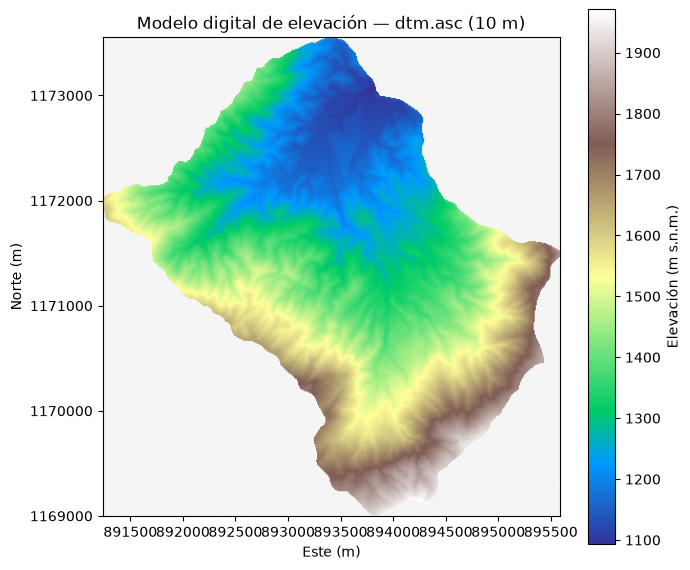

In [14]:
mapa_dtm = plt.get_cmap("terrain").copy()
mapa_dtm.set_bad(color="whitesmoke")

fig, ax = plt.subplots(figsize=(7, 7))
img = ax.imshow(dtm_mask, cmap=mapa_dtm, extent=extension_dtm, origin="upper")

ax.set_title("Modelo digital de elevación — dtm.asc (10 m)")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")
ax.ticklabel_format(style="plain")

barra = fig.colorbar(img, ax=ax, shrink=0.8)
barra.set_label("Elevación (m s.n.m.)")

plt.tight_layout()
plt.show()

Dos representaciones complementarias: las curvas de nivel, que hacen legible la forma del relieve, y el histograma, que muestra cómo se distribuyen las elevaciones.

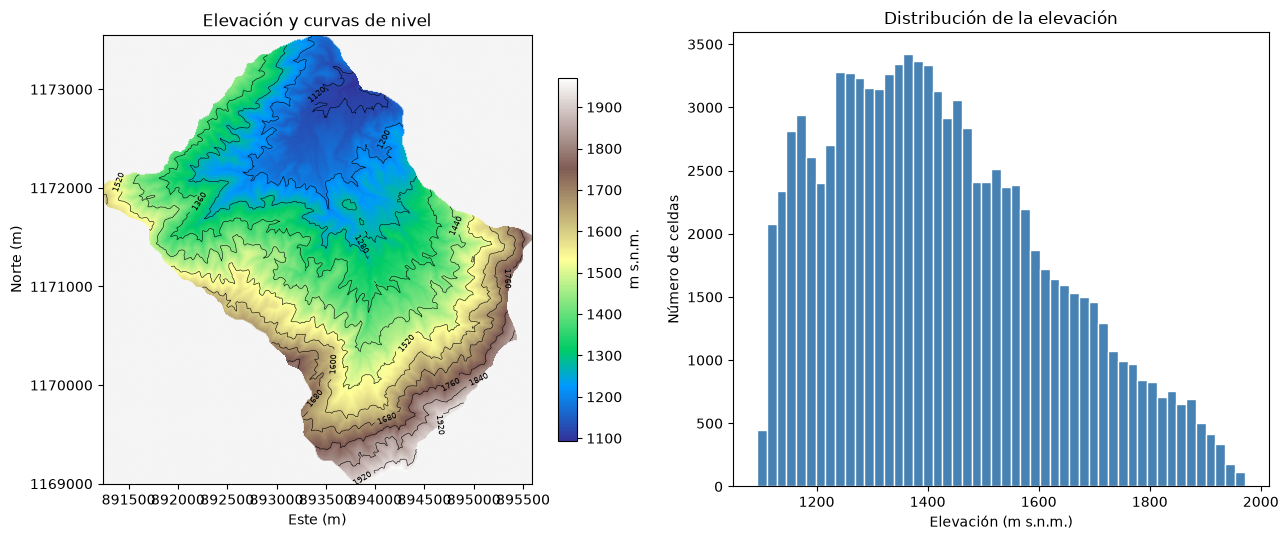

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

img = ax1.imshow(dtm_mask, cmap=mapa_dtm, extent=extension_dtm, origin="upper")
curvas = ax1.contour(dtm_mask, levels=12, colors="k", linewidths=0.4,
                     extent=extension_dtm, origin="upper")
ax1.clabel(curvas, inline=True, fontsize=6, fmt="%.0f")
ax1.set_title("Elevación y curvas de nivel")
ax1.set_xlabel("Este (m)")
ax1.set_ylabel("Norte (m)")
ax1.ticklabel_format(style="plain")
fig.colorbar(img, ax=ax1, shrink=0.8, label="m s.n.m.")

ax2.hist(dtm_mask.compressed(), bins=50, color="steelblue", edgecolor="white")
ax2.set_title("Distribución de la elevación")
ax2.set_xlabel("Elevación (m s.n.m.)")
ax2.set_ylabel("Número de celdas")

plt.tight_layout()
plt.show()

## 7. Sombreado del relieve (*hillshade*)

Un mapa de elevación en colores dice a qué altura está cada punto, pero cuesta leer la forma del terreno: dónde va una divisoria, dónde se encaja una quebrada. El **sombreado del relieve** resuelve eso simulando cómo iluminaría la superficie un sol colocado en una posición determinada. Es una técnica de representación, no una variable del terreno: el resultado depende de dónde se ponga el sol.

El cálculo necesita tres ingredientes, todos derivados del modelo de elevación:

1. La **pendiente** de cada celda: qué tan inclinada está.
2. La **orientación** o aspecto: hacia qué punto cardinal mira esa inclinación.
3. La posición del sol, dada por su **azimut** (dirección de donde viene la luz, en grados desde el norte y en sentido horario) y su **altitud** sobre el horizonte.

Por convención cartográfica el sol se sitúa en el noroeste (azimut 315°) y a 45° sobre el horizonte. No es una elección física —en el hemisferio norte el sol nunca ilumina desde el norte— sino perceptual: el cerebro interpreta como relieve una escena iluminada desde arriba a la izquierda, y como hueco la misma escena iluminada desde abajo a la derecha.

### 7.1 Gradientes del terreno

`np.gradient` calcula la variación de la elevación en cada dirección. Pasándole el tamaño de celda, el resultado queda en metros por metro, es decir, adimensional.

Hay que cuidar la convención de signos. `np.gradient` devuelve primero la variación a lo largo del eje 0 —las filas, que avanzan hacia el **sur**— y luego la del eje 1 —las columnas, que avanzan hacia el **este**—. Para trabajar en términos geográficos se invierte el signo de la primera.

Las celdas sin dato se convierten a `NaN` antes de derivar: así el `NaN` se propaga al borde en lugar de producir un acantilado ficticio de 10.000 m contra las celdas `-9999`.

In [16]:
z = dtm_mask.filled(np.nan).astype("float64")   # NODATA -> NaN

d_fila, d_columna = np.gradient(z, cellsize)

dz_este = d_columna      # X crece hacia el este
dz_norte = -d_fila       # las filas avanzan hacia el sur: se invierte el signo

print("Variación máxima hacia el este :", f"{np.nanmax(np.abs(dz_este)):.2f} m/m")
print("Variación máxima hacia el norte:", f"{np.nanmax(np.abs(dz_norte)):.2f} m/m")

Variación máxima hacia el este : 1.92 m/m
Variación máxima hacia el norte: 1.69 m/m


### 7.2 Pendiente y orientación

La pendiente es el arcotangente de la magnitud del gradiente. La orientación es la dirección hacia la que desciende el terreno, expresada como un azimut de 0° a 360°: el gradiente apunta hacia arriba, así que la dirección de descenso es la opuesta, de ahí los signos negativos dentro de `arctan2`.

El factor de exageración vertical `z_factor` multiplica el gradiente. Vale 1 cuando la elevación está en las mismas unidades que las coordenadas —como aquí, metros y metros—, y se usa distinto de 1 solo para exagerar el relieve con fines visuales.

In [17]:
z_factor = 1.0

pendiente_rad = np.arctan(z_factor * np.hypot(dz_este, dz_norte))
pendiente_deg = np.degrees(pendiente_rad)

# azimut de descenso: 0° = norte, 90° = este, en sentido horario
aspecto_rad = np.arctan2(-dz_este, -dz_norte) % (2 * np.pi)
aspecto_deg = np.degrees(aspecto_rad)

print(f"Pendiente media  : {np.nanmean(pendiente_deg):.1f}°")
print(f"Pendiente máxima : {np.nanmax(pendiente_deg):.1f}°")

Pendiente media  : 28.9°
Pendiente máxima : 63.8°


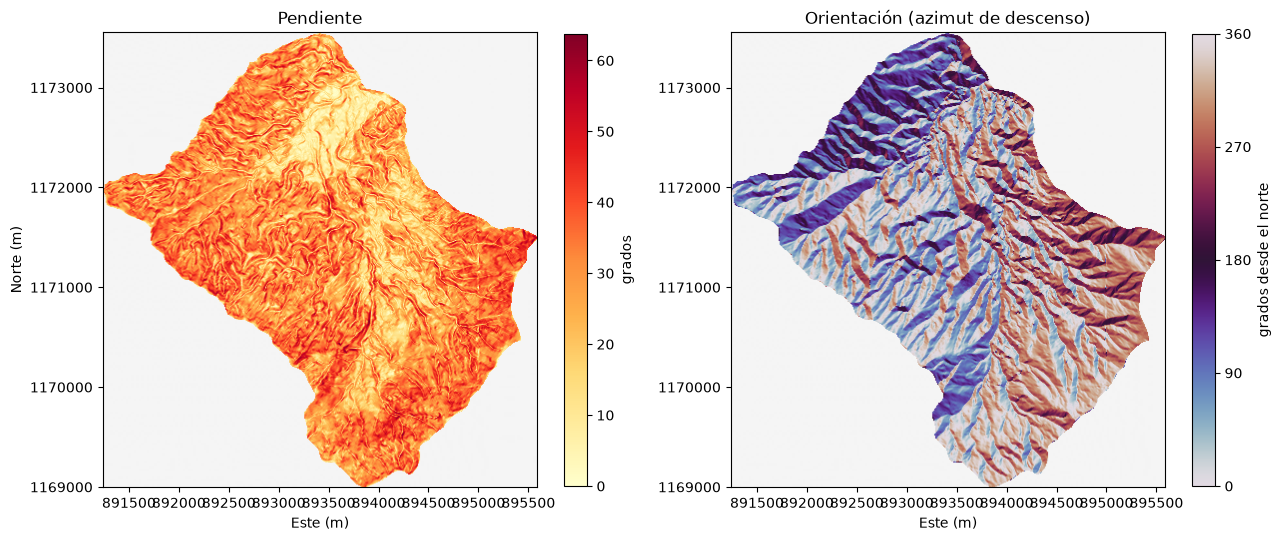

In [18]:
mapa_pend = plt.get_cmap("YlOrRd").copy()
mapa_pend.set_bad(color="whitesmoke")
mapa_asp = plt.get_cmap("twilight").copy()      # cíclico: 0° y 360° son el mismo color
mapa_asp.set_bad(color="whitesmoke")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

img1 = ax1.imshow(pendiente_deg, cmap=mapa_pend, extent=extension_dtm, origin="upper")
ax1.set_title("Pendiente")
fig.colorbar(img1, ax=ax1, shrink=0.8, label="grados")

img2 = ax2.imshow(aspecto_deg, cmap=mapa_asp, vmin=0, vmax=360,
                  extent=extension_dtm, origin="upper")
ax2.set_title("Orientación (azimut de descenso)")
fig.colorbar(img2, ax=ax2, shrink=0.8, ticks=[0, 90, 180, 270, 360],
             label="grados desde el norte")

for eje in (ax1, ax2):
    eje.set_xlabel("Este (m)")
    eje.ticklabel_format(style="plain")
ax1.set_ylabel("Norte (m)")

plt.tight_layout()
plt.show()

### 7.3 La fórmula del sombreado

Con la pendiente y la orientación, el sombreado es el coseno del ángulo entre la normal a la superficie y el rayo de luz. La expresión estándar es:

$$\text{hillshade} = 255 \; [\; \cos(z_{\text{cenital}})\cos(\beta) + \sin(z_{\text{cenital}})\sin(\beta)\cos(\alpha_{\text{sol}} - \alpha_{\text{terreno}}) \;]$$

donde $\beta$ es la pendiente, $\alpha_{\text{terreno}}$ la orientación de la celda, $\alpha_{\text{sol}}$ el azimut del sol y $z_{\text{cenital}} = 90° - \text{altitud solar}$.

El resultado se expresa de 0 a 255 —la escala de una imagen en tonos de gris— y se recorta en 0 porque los valores negativos corresponden a caras que dan la espalda al sol: geométricamente están en sombra propia, y el valor negativo no aporta información adicional.

In [19]:
def hillshade(pendiente_rad, aspecto_rad, azimut=315.0, altitud=45.0):
    """Sombreado del relieve a partir de la pendiente y la orientación (en radianes).

    azimut  : dirección de donde viene la luz, en grados desde el norte (horario).
    altitud : altura del sol sobre el horizonte, en grados.
    """
    cenital_rad = np.radians(90.0 - altitud)
    azimut_rad = np.radians(azimut)

    sombreado = (np.cos(cenital_rad) * np.cos(pendiente_rad) +
                 np.sin(cenital_rad) * np.sin(pendiente_rad) *
                 np.cos(azimut_rad - aspecto_rad))

    return np.clip(255 * sombreado, 0, 255)


sombra = hillshade(pendiente_rad, aspecto_rad, azimut=315, altitud=45)

print("Rango del sombreado:", f"{np.nanmin(sombra):.0f} a {np.nanmax(sombra):.0f}")

Rango del sombreado: 0 a 255


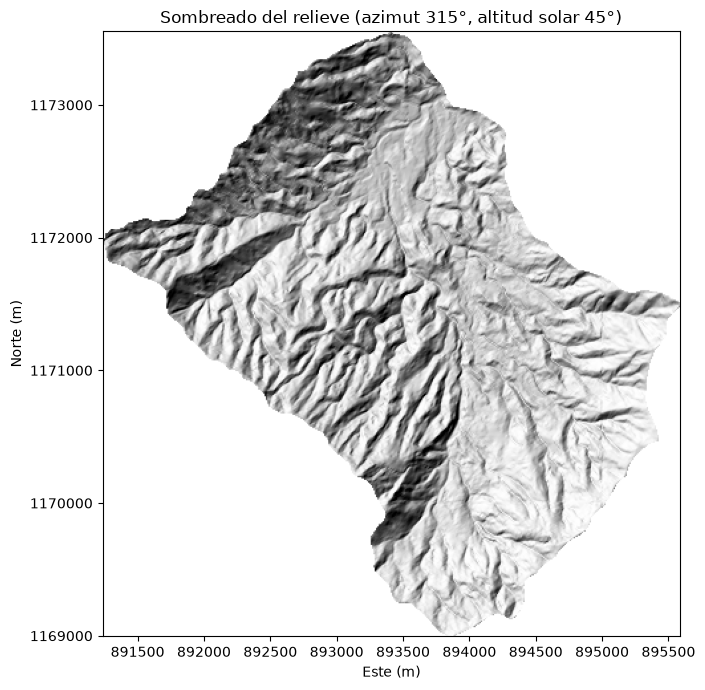

In [20]:
mapa_gris = plt.get_cmap("gray").copy()
mapa_gris.set_bad(color="white")

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(sombra, cmap=mapa_gris, vmin=0, vmax=255,
          extent=extension_dtm, origin="upper")

ax.set_title("Sombreado del relieve (azimut 315°, altitud solar 45°)")
ax.set_xlabel("Este (m)")
ax.set_ylabel("Norte (m)")
ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.show()

### 7.4 El efecto de la posición del sol

Cambiar el azimut no cambia el terreno, pero sí lo que se ve. Con el sol en el sureste (135°) la imagen se percibe invertida: las cuchillas parecen cañones y los valles parecen lomos. Es la **inversión del relieve**, y es la razón por la que la convención de iluminar desde el noroeste conviene respetarse.

Bajar la altitud solar, por su parte, alarga las sombras y realza los detalles del relieve suave, a costa de saturar en negro las laderas más inclinadas.

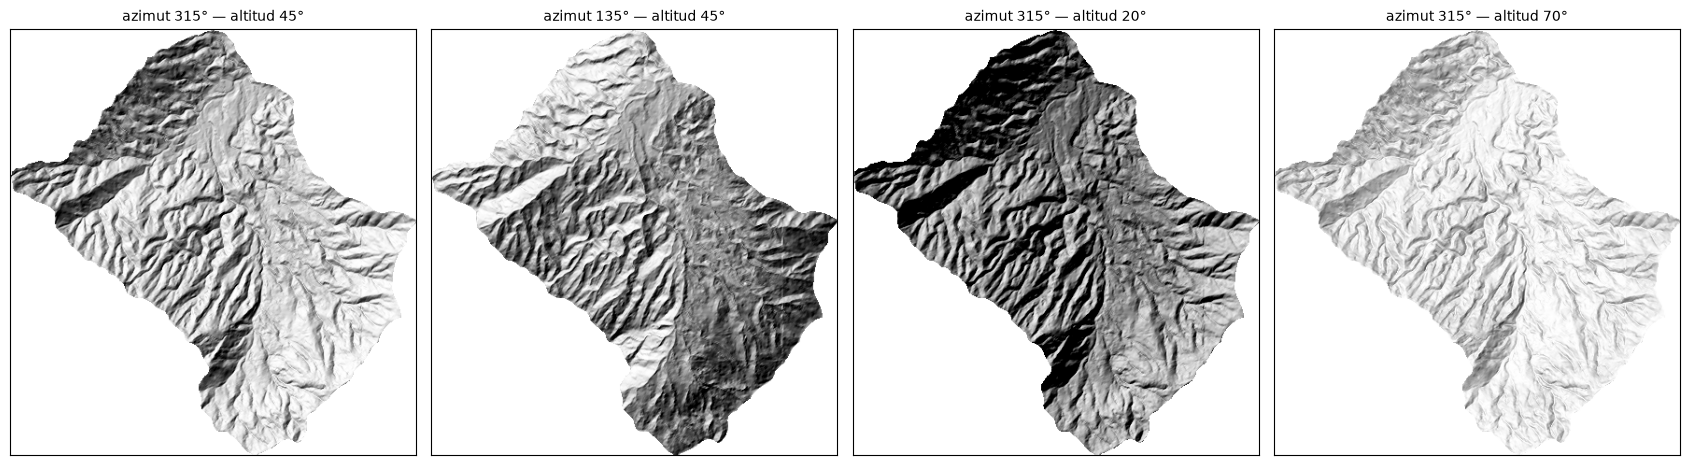

In [21]:
configuraciones = [(315, 45), (135, 45), (315, 20), (315, 70)]

fig, ejes = plt.subplots(1, 4, figsize=(17, 4.6))

for eje, (az, alt) in zip(ejes, configuraciones):
    eje.imshow(hillshade(pendiente_rad, aspecto_rad, azimut=az, altitud=alt),
               cmap=mapa_gris, vmin=0, vmax=255,
               extent=extension_dtm, origin="upper")
    eje.set_title(f"azimut {az}° — altitud {alt}°", fontsize=10)
    eje.set_xticks([])
    eje.set_yticks([])

plt.tight_layout()
plt.show()

### 7.5 El atajo: LightSource de matplotlib

Todo lo anterior está implementado en `matplotlib.colors.LightSource`, que aplica la misma formulación. Vale la pena compararlo con el cálculo manual para confirmar que hacen lo mismo: la correlación entre ambos resultados es prácticamente 1.

`LightSource` no maneja `NaN`, así que se le pasa el arreglo relleno y la máscara se vuelve a aplicar después.

In [22]:
from matplotlib.colors import LightSource

luz = LightSource(azdeg=315, altdeg=45)

z_relleno = dtm_mask.filled(float(dtm_mask.mean()))
sombra_mpl = luz.hillshade(z_relleno, vert_exag=1, dx=cellsize, dy=cellsize) * 255
sombra_mpl = np.where(dtm_mask.mask, np.nan, sombra_mpl)

validas = np.isfinite(sombra) & np.isfinite(sombra_mpl)
correlacion = np.corrcoef(sombra[validas], sombra_mpl[validas])[0, 1]

print(f"Correlación entre el cálculo manual y LightSource: {correlacion:.5f}")

Correlación entre el cálculo manual y LightSource: 0.99985


La utilidad real de `LightSource` está en `shade`, que combina el sombreado con una rampa de color en una sola imagen. El relieve aporta la forma y el color aporta la variable: es la representación estándar de un modelo de elevación.

`blend_mode` controla cómo se mezclan; `"overlay"` y `"soft"` conservan mejor el color que el producto directo. El `vert_exag` sí conviene subirlo aquí, porque la mezcla apaga el contraste del sombreado.

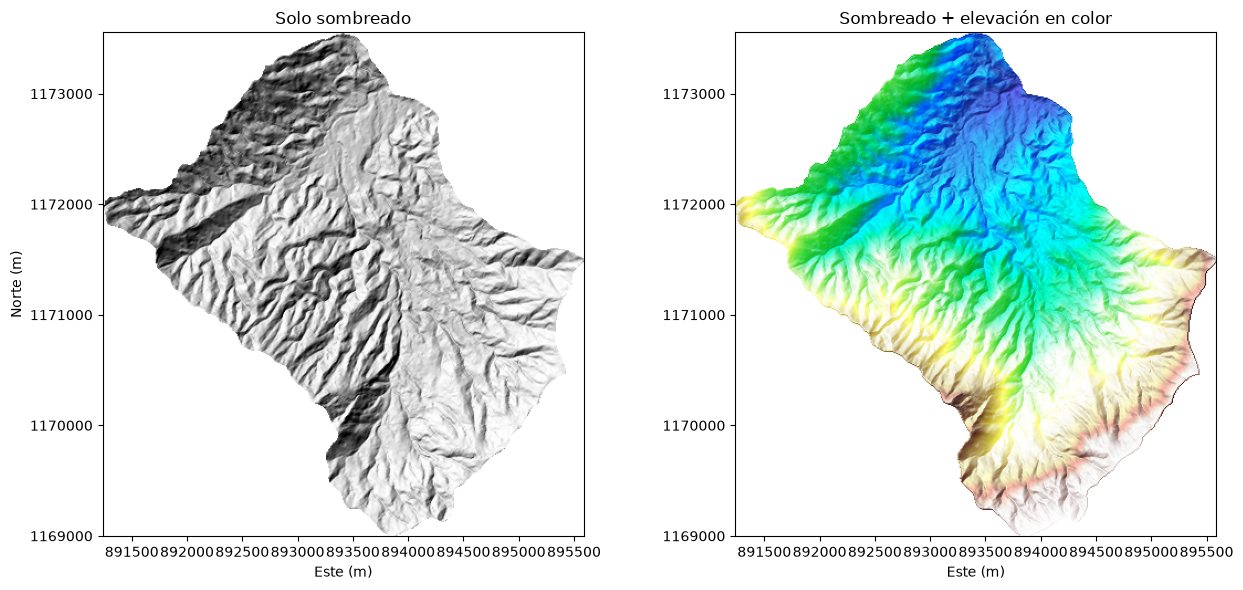

In [23]:
rgb = luz.shade(z_relleno, cmap=plt.get_cmap("terrain"), blend_mode="overlay",
                vert_exag=3, dx=cellsize, dy=cellsize)
rgb[dtm_mask.mask] = 1.0        # celdas sin dato en blanco

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.imshow(sombra, cmap=mapa_gris, vmin=0, vmax=255,
           extent=extension_dtm, origin="upper")
ax1.set_title("Solo sombreado")

ax2.imshow(rgb, extent=extension_dtm, origin="upper")
ax2.set_title("Sombreado + elevación en color")

for eje in (ax1, ax2):
    eje.set_xlabel("Este (m)")
    eje.ticklabel_format(style="plain")
ax1.set_ylabel("Norte (m)")

plt.tight_layout()
plt.show()

### 7.6 Guardar el sombreado como raster

El sombreado es un raster nuevo: comparte malla, extensión y resolución con el modelo de elevación, así que se escribe reutilizando su perfil. Basta ajustar el tipo de dato y volver a poner el `NODATA` donde había `NaN`.

In [ ]:
with rasterio.open("dtm.tif","w",driver="GTiff", dtype="float32", nodata=-9999.0,
              width=435, height=456, count=1, crs=None,
              blockxsize=435, blockysize=1, tiled=False, compress="lzw") as dst:
    dst.write(np.nan_to_num(dtm, nan=-9999.0).astype("float32"), 1)

Archivo : dtm_hillshade.tif
Driver  : GTiff
Tipo    : float32
Extensión igual a la del MDE: True
Tamaño  : 456 KB


## 8. Un ASCII Grid con extensión `.txt`

El segundo archivo, `geologia.txt`, contiene las unidades geológicas de otra ladera. La extensión sugiere un texto cualquiera, pero el contenido dice otra cosa.

Es un ASCII Grid, con la misma cabecera de seis líneas. **La extensión de un archivo no define su formato**: lo que importa es el contenido. GDAL —y por tanto `rasterio`— identifica el formato leyendo el comienzo del archivo, así que lo abre sin problema aunque se llame `.txt`.

En sentido contrario, un archivo llamado `.asc` que no tenga esa estructura no será un ASCII Grid por más que la extensión lo sugiera.

In [ ]:
with rasterio.open(ruta_geologia) as src:
    geologia = src.read(1, masked=True)

Driver      : AAIGrid
Dimensiones : 1868 filas x 519 columnas
Tipo de dato: int32
Resolución  : (10.0, 10.0) m
NODATA      : -9999.0
CRS         : None
Extensión   : BoundingBox(left=829734.05499953, bottom=1135774.0875265, right=834924.05499953, top=1154454.0875265)

Celdas válidas: 578,739 de 969,492 (59.7 %)


In [27]:
codigos, conteos = np.unique(geologia.compressed(), return_counts=True)

unidades = pd.DataFrame({
    "codigo": codigos,
    "celdas": conteos,
    "area_ha": conteos * 10 * 10 / 10_000,     # celdas de 10 x 10 m
})
unidades["porcentaje"] = 100 * unidades["celdas"] / unidades["celdas"].sum()
unidades.round(1)

,codigo,celdas,area_ha,porcentaje
0,18,263124,2631.2,45.5
1,19,3245,32.4,0.6
2,22,34525,345.2,6.0
3,25,6363,63.6,1.1
4,27,12969,129.7,2.2
5,28,184175,1841.8,31.8
6,30,74338,743.4,12.8


Siete unidades, identificadas por códigos que no son consecutivos (18, 19, 22, 25, 27, 28, 30). Es un raster **categórico**: los números son etiquetas, no cantidades. Calcular su media no significaría nada, y representarlo con una rampa continua sugeriría un orden que no existe.

Para darle a cada unidad un color bien diferenciado conviene **reasignar** cada código a un índice de 0 a 6, colorear por ese índice y luego etiquetar la barra de color con los códigos originales. `np.searchsorted` hace la reasignación.

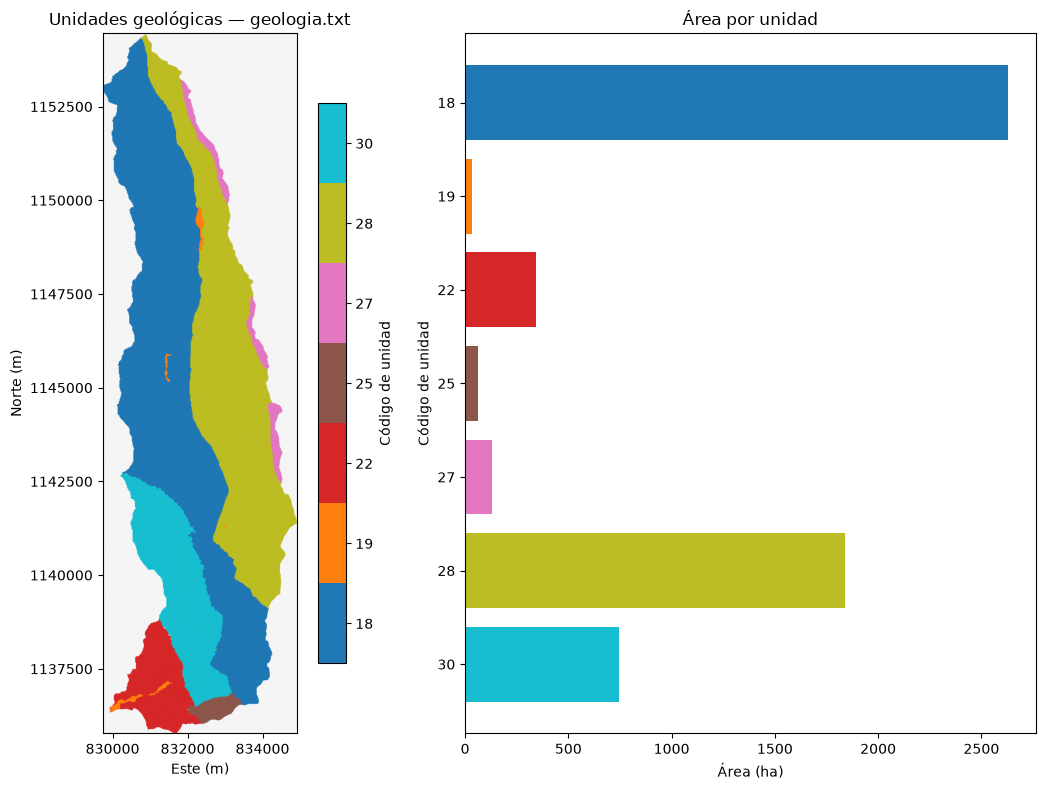

In [28]:
from matplotlib.colors import ListedColormap

# se rellena con el primer código solo para poder indexar; la máscara se conserva aparte
indices = np.searchsorted(codigos, geologia.filled(codigos[0]))
geologia_idx = np.ma.masked_array(indices, mask=geologia.mask)

base_geo = plt.get_cmap("tab10", len(codigos))
mapa_geo = ListedColormap([base_geo(i) for i in range(len(codigos))])
mapa_geo.set_bad(color="whitesmoke")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 8),
                               gridspec_kw={"width_ratios": [1, 1.4]})

img = ax1.imshow(geologia_idx, cmap=mapa_geo, vmin=-0.5, vmax=len(codigos) - 0.5,
                 extent=extension_geo, origin="upper")
ax1.set_title("Unidades geológicas — geologia.txt")
ax1.set_xlabel("Este (m)")
ax1.set_ylabel("Norte (m)")
ax1.ticklabel_format(style="plain")

barra = fig.colorbar(img, ax=ax1, ticks=range(len(codigos)), shrink=0.8)
barra.ax.set_yticklabels(codigos)
barra.set_label("Código de unidad")

ax2.barh(unidades["codigo"].astype(str), unidades["area_ha"],
         color=[base_geo(i) for i in range(len(codigos))])
ax2.set_title("Área por unidad")
ax2.set_xlabel("Área (ha)")
ax2.set_ylabel("Código de unidad")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Exportar a GeoTIFF y asignar el CRS

El ASCII Grid es legible y fácil de intercambiar, pero cada valor se guarda como texto: ocupa mucho y se lee lento. Para trabajar, el formato habitual es GeoTIFF, que es binario, comprimido, admite varias bandas y —lo que aquí más importa— **lleva el CRS incorporado en el propio archivo**.

Al exportar se aprovecha para asignar el sistema de referencia que faltaba. Se usa EPSG:3116 (MAGNA-SIRGAS / Colombia Bogotá zone), coherente con la magnitud de las coordenadas. Conviene subrayar que esto no reproyecta nada: solo declara en qué sistema están las coordenadas que el archivo ya tiene. Asignar un CRS equivocado no mueve los datos, pero los ubica mal respecto a cualquier otra capa.

In [32]:
from rasterio.crs import CRS

crs_magna = CRS.from_epsg(3116)

ruta_tif = DIR_SALIDA / "dtm.tif"

with rasterio.open(ruta_dtm) as src:
    perfil_tif = src.profile.copy()
    perfil_tif.update(driver="GTiff", crs=crs_magna, compress="lzw")
    datos = src.read(1)

with rasterio.open(ruta_tif, "w", **perfil_tif) as dst:
    dst.write(datos, 1)

kb_asc = ruta_dtm.stat().st_size / 1024
kb_tif = ruta_tif.stat().st_size / 1024
print(f"ASCII Grid : {kb_asc:8.1f} KB")
print(f"GeoTIFF    : {kb_tif:8.1f} KB  ({kb_asc / kb_tif:.1f} veces más pequeño)")

ASCII Grid :   1397.8 KB
GeoTIFF    :    398.5 KB  (3.5 veces más pequeño)


In [33]:
with rasterio.open(ruta_tif) as src:
    print("CRS del GeoTIFF:", src.crs)
    print("Extensión      :", src.bounds)
    print("Compresión     :", src.compression)

CRS del GeoTIFF: EPSG:3116
Extensión      : BoundingBox(left=891236.30040912, bottom=1168994.6457458, right=895586.30040912, top=1173554.6457458)
Compresión     : Compression.lzw


Si por alguna razón conviene conservar el formato ASCII —por ejemplo porque un modelo lo exige como entrada—, el CRS se puede declarar escribiendo un archivo `.prj` con el mismo nombre base. GDAL lo busca automáticamente al abrir el `.asc`.

In [34]:
ruta_asc_copia = DIR_SALIDA / "dtm.asc"

with rasterio.open(ruta_dtm) as src:
    perfil_asc = src.profile.copy()
    datos = src.read(1)

with rasterio.open(ruta_asc_copia, "w", **perfil_asc) as dst:
    dst.write(datos, 1)

# el .prj es un archivo de texto con el CRS en formato WKT
ruta_asc_copia.with_suffix(".prj").write_text(crs_magna.to_wkt())

with rasterio.open(ruta_asc_copia) as src:
    print("CRS de la copia con .prj:", src.crs)

print("\nInicio del WKT:")
print(crs_magna.to_wkt()[:200], "...")

CRS de la copia con .prj: EPSG:3116

Inicio del WKT:
PROJCS["MAGNA-SIRGAS / Colombia Bogota zone",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG" ...


## 11. Importar un GeoTIFF desde internet

Hasta aquí los archivos estaban en el disco. `rasterio` —a través de GDAL— también abre rasters remotos por HTTP sin descargarlos completos, leyendo solo los bloques que se piden. Eso lo hace el sistema de archivos virtual `/vsicurl/`, que se activa al pasar directamente una URL.

Se usa el raster **GHSL** (*Global Human Settlement Layer*) de São Paulo que acompaña al libro [Geographic Data Science with Python](https://geographicdata.science/book/). Cada celda contiene la superficie construida, en metros cuadrados, dentro de esa celda.

In [35]:
url_ghsl = ("https://raw.githubusercontent.com/gdsbook/book/main/"
            "data/ghsl/ghsl_sao_paulo.tif")

with rasterio.open(url_ghsl) as src:
    perfil_ghsl = src.profile

perfil_ghsl

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -200.0, 'width': 468, 'height': 416, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(250.0, 0.0, -4482000.0,
       0.0, -250.0, -2822000.0), 'blockxsize': 468, 'blockysize': 4, 'tiled': False, 'interleave': 'band'}

Si se prefiere tener una copia local —por ejemplo para trabajar sin conexión, o porque el raster se va a leer muchas veces— se descarga con `urllib` y se abre desde el disco. Ambas rutas son equivalentes de aquí en adelante.

In [36]:
from urllib.request import urlretrieve


def descargar(url, destino):
    """Descarga la url solo si el archivo no existe ya en el disco."""
    if not destino.exists():
        urlretrieve(url, destino)
    return destino


ruta_ghsl = descargar(url_ghsl, DIR_SALIDA / "ghsl_sao_paulo.tif")

print("Archivo local:", ruta_ghsl.resolve())
print(f"Tamaño: {ruta_ghsl.stat().st_size / 1024**2:.2f} MB")

Archivo local: C:\Users\edier\Documents\CATEDRA\ANALISISGEOESPACIAL\AnalisisGeoespacial\Notebooks\data\salidas\ghsl_sao_paulo.tif
Tamaño: 0.74 MB


### Propiedades del GeoTIFF

Un GeoTIFF guarda internamente todo lo que en el ASCII Grid estaba repartido entre la cabecera y el `.prj`, y además información sobre cómo están organizados los datos dentro del archivo: bloques (*tiles*), compresión y pirámides de resolución (*overviews*).

In [37]:
with rasterio.open(ruta_ghsl) as src:
    print("Driver        :", src.driver)
    print("Dimensiones   :", f"{src.height} filas x {src.width} columnas")
    print("Número de bandas:", src.count)
    print("Índices de banda:", src.indexes)
    print("Tipos de dato :", src.dtypes)
    print("NODATA        :", src.nodata)
    print("CRS           :", src.crs)
    print("Resolución    :", src.res, "m")
    print("Extensión     :", src.bounds)
    print("Transformación:")
    print(src.transform)
    print("Compresión    :", src.compression)
    print("Overviews b1  :", src.overviews(1))

Driver        : GTiff
Dimensiones   : 416 filas x 468 columnas
Número de bandas: 1
Índices de banda: (1,)
Tipos de dato : ('float32',)
NODATA        : -200.0
CRS           : ESRI:54009
Resolución    : (250.0, 250.0) m
Extensión     : BoundingBox(left=-4482000.0, bottom=-2926000.0, right=-4365000.0, top=-2822000.0)
Transformación:
| 250.00, 0.00,-4482000.00|
| 0.00,-250.00,-2822000.00|
| 0.00, 0.00, 1.00|
Compresión    : None
Overviews b1  : []


El CRS `ESRI:54009` es la proyección de Mollweide, equivalente en área. Es la que usa GHSL porque los valores son superficies: si se reproyectara a un sistema que no conserva el área, los metros cuadrados por celda dejarían de ser comparables entre el ecuador y las latitudes altas.

### Seleccionar bandas

`src.read()` sin argumentos devuelve **todas** las bandas en un arreglo tridimensional con forma `(bandas, filas, columnas)`. Pasando un número se obtiene una sola banda, en un arreglo bidimensional; pasando una lista, un subconjunto.

Las bandas se numeran **desde 1**, no desde 0, siguiendo la convención de GDAL. `src.indexes` dice cuáles existen.

In [38]:
with rasterio.open(ruta_ghsl) as src:
    todas = src.read()                    # (bandas, filas, columnas)
    banda1 = src.read(1)                  # (filas, columnas)
    subconjunto = src.read([1])           # (1, filas, columnas)

print("src.read()   ->", todas.shape)
print("src.read(1)  ->", banda1.shape)
print("src.read([1])->", subconjunto.shape)

src.read()   -> (1, 416, 468)
src.read(1)  -> (416, 468)
src.read([1])-> (1, 416, 468)


Este raster tiene una sola banda, así que solo el índice `1` es válido; pedir la banda 2 lanza un error. En una imagen multiespectral —Landsat, Sentinel-2— la selección sería `src.read([4, 3, 2])` para armar una composición en color verdadero, y `src.descriptions` suele traer el nombre de cada banda.

In [39]:
with rasterio.open(ruta_ghsl) as src:
    print("Descripciones de banda:", src.descriptions)
    print("Unidades              :", src.units)
    try:
        src.read(2)
    except IndexError as error:
        print("\nPedir la banda 2 falla:", error)

Descripciones de banda: (None,)
Unidades              : (None,)

Pedir la banda 2 falla: band index 2 out of range (not in (1,))


Para un raster grande no hace falta leerlo completo. Dos estrategias habituales: leer una **ventana** (un recorte por filas y columnas) o hacer una lectura **decimada**, que usa `out_shape` para traer una versión reducida —útil para una vista rápida.

In [40]:
from rasterio.windows import Window

with rasterio.open(ruta_ghsl) as src:
    ventana = Window(col_off=150, row_off=120, width=200, height=180)
    recorte = src.read(1, window=ventana, masked=True)
    transform_recorte = src.window_transform(ventana)

    vista_rapida = src.read(1, masked=True,
                            out_shape=(src.height // 4, src.width // 4))

print("Recorte      :", recorte.shape)
print("Vista rápida :", vista_rapida.shape)

Recorte      : (180, 200)
Vista rápida : (104, 117)


### Representar el GeoTIFF

El valor `NODATA` de este raster es `-200`, así que se lee con `masked=True`. La superficie construida está muy sesgada —muchas celdas con poco o nada y unas pocas con valores altos—, por lo que una escala lineal dejaría el mapa casi vacío. Se recorta la escala en el percentil 98.

In [41]:
with rasterio.open(ruta_ghsl) as src:
    ghsl = src.read(1, masked=True)
    extension_ghsl = [src.bounds.left, src.bounds.right,
                      src.bounds.bottom, src.bounds.top]

print(f"Mínimo  : {ghsl.min():.1f} m²")
print(f"Máximo  : {ghsl.max():.1f} m²")
print(f"Media   : {ghsl.mean():.1f} m²")
print(f"Celdas válidas: {ghsl.count():,} de {ghsl.size:,}")

vmax = np.percentile(ghsl.compressed(), 98)
print(f"Percentil 98: {vmax:.0f} m²")

Mínimo  : 0.0 m²
Máximo  : 6563.0 m²
Media   : 223.0 m²
Celdas válidas: 97,232 de 194,688
Percentil 98: 1647 m²


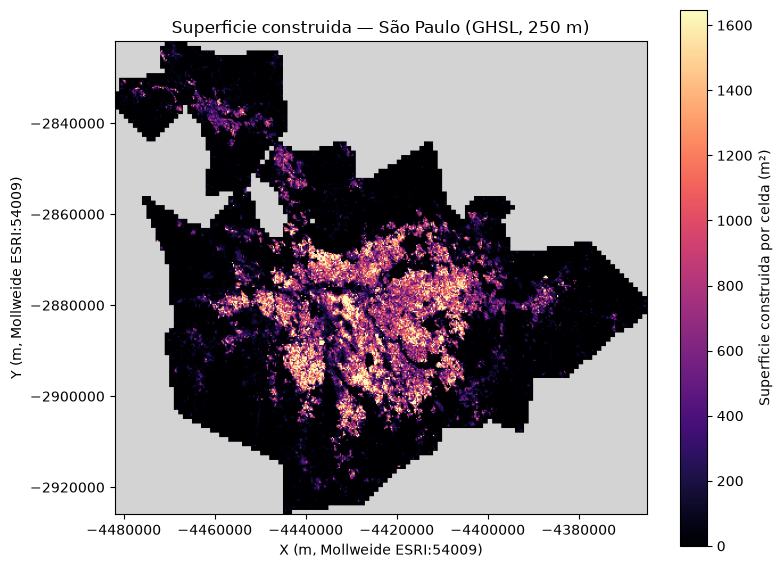

In [42]:
mapa_ghsl = plt.get_cmap("magma").copy()
mapa_ghsl.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(ghsl, cmap=mapa_ghsl, extent=extension_ghsl,
                origin="upper", vmin=0, vmax=vmax)

ax.set_title("Superficie construida — São Paulo (GHSL, 250 m)")
ax.set_xlabel("X (m, Mollweide ESRI:54009)")
ax.set_ylabel("Y (m, Mollweide ESRI:54009)")
ax.ticklabel_format(style="plain")

barra = fig.colorbar(img, ax=ax, shrink=0.8)
barra.set_label("Superficie construida por celda (m²)")

plt.tight_layout()
plt.show()

`rasterio.plot.show` hace lo mismo en una línea: toma el objeto abierto, lee la banda indicada y usa su transformación para poner las coordenadas en los ejes. Es cómodo para exploración; para figuras cuidadas conviene el control explícito de `imshow`.

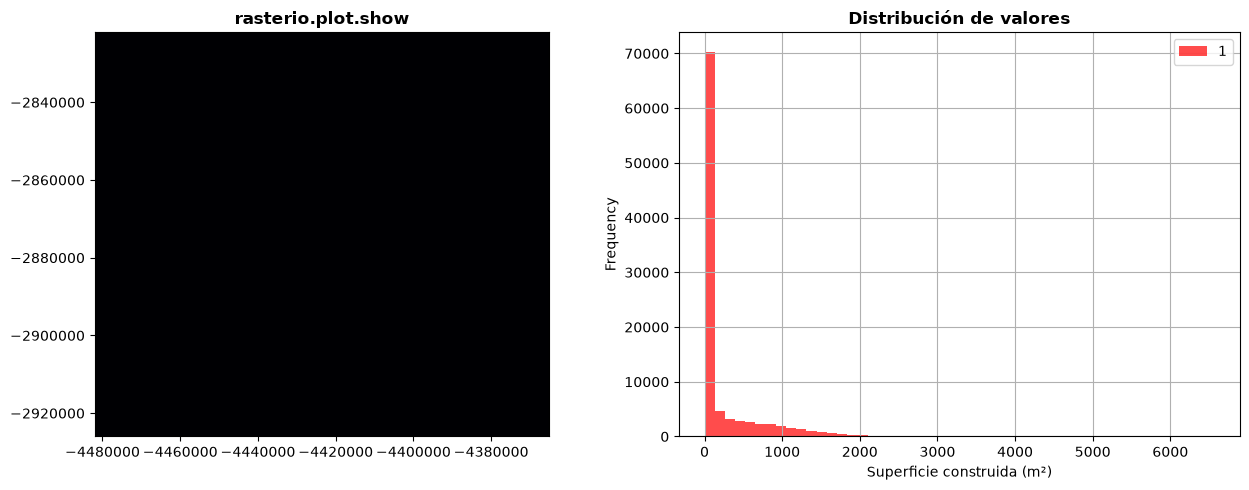

In [43]:
from rasterio.plot import show, show_hist

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

with rasterio.open(ruta_ghsl) as src:
    show((src, 1), ax=ax1, cmap="magma", vmin=0, vmax=vmax,
         title="rasterio.plot.show")
    show_hist(src, bins=50, ax=ax2, lw=0, stacked=False, alpha=0.7,
              histtype="stepfilled", title="Distribución de valores")

ax1.ticklabel_format(style="plain")
ax2.set_xlabel("Superficie construida (m²)")
plt.tight_layout()
plt.show()

Una comparación entre el recorte por ventana y la vista decimada deja ver para qué sirve cada lectura parcial: la ventana conserva la resolución original sobre un área menor; la decimada cubre todo el raster con menos celdas.

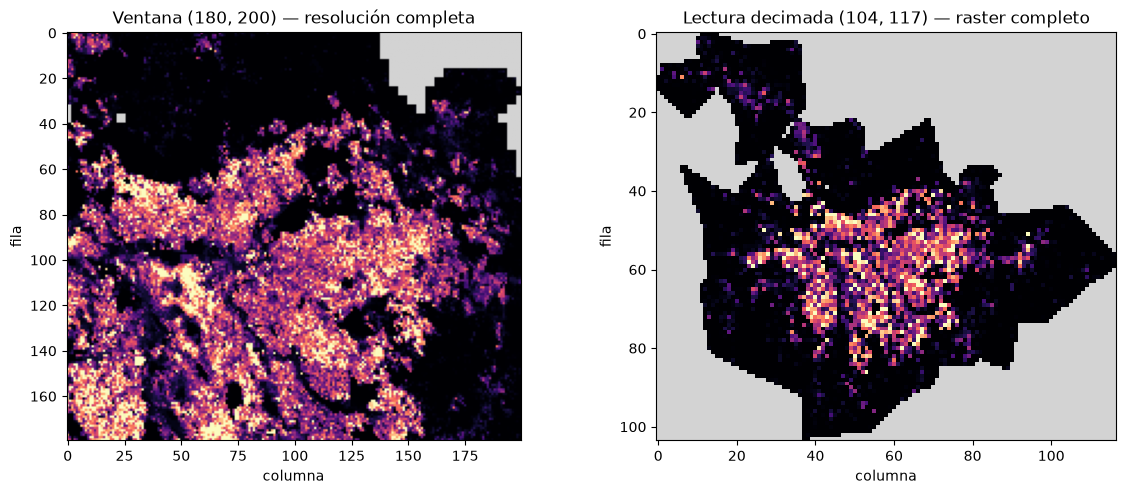

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(recorte, cmap=mapa_ghsl, vmin=0, vmax=vmax)
ax1.set_title(f"Ventana {recorte.shape} — resolución completa")

ax2.imshow(vista_rapida, cmap=mapa_ghsl, vmin=0, vmax=vmax)
ax2.set_title(f"Lectura decimada {vista_rapida.shape} — raster completo")

for eje in (ax1, ax2):
    eje.set_xlabel("columna")
    eje.set_ylabel("fila")

plt.tight_layout()
plt.show()

## 12. Cloud Optimized GeoTIFF (COG)

Un **COG** no es un formato nuevo: es un GeoTIFF normal, que cualquier programa abre como tal, organizado internamente de una manera que permite leer pedazos por HTTP sin descargar el archivo completo. La diferencia está en tres decisiones de escritura:

1. **Teselas en lugar de franjas.** Un GeoTIFF por defecto se guarda por franjas (*stripes*): filas completas, una tras otra. Para extraer un cuadrado del centro hay que leer todas las filas que lo cruzan, de borde a borde. Un COG se guarda en teselas cuadradas (256×256 o 512×512), así que ese mismo cuadrado son unas pocas teselas contiguas.
2. **Pirámides internas (*overviews*).** Versiones reducidas de la imagen guardadas dentro del mismo archivo. Para dibujar una vista general no hay que leer la resolución completa.
3. **Un orden interno conocido**, con las cabeceras al comienzo, de modo que un cliente pueda pedir por HTTP solo los bytes que necesita (*range requests*).

### 12.1 Comparar un GeoTIFF normal con un COG

El GeoTIFF exportado en la sección 10 sirve de referencia. Se escribe ahora el mismo dato con el driver `COG` y se comparan sus estructuras internas.

In [45]:
ruta_cog = DIR_SALIDA / "dtm_cog.tif"

with rasterio.open(ruta_dtm) as src:
    perfil_cog = src.profile.copy()
    datos = src.read(1)

# el driver COG decide él mismo el teselado y el entrelazado
for clave in ("tiled", "blockxsize", "blockysize", "interleave"):
    perfil_cog.pop(clave, None)

perfil_cog.update(driver="COG", crs=crs_magna, compress="lzw",
                  blocksize=256, overview_resampling="average")

with rasterio.open(ruta_cog, "w", **perfil_cog) as dst:
    dst.write(datos, 1)

print("Escrito:", ruta_cog.name)

Escrito: dtm_cog.tif


In [46]:
filas = []
for nombre, ruta in [("GeoTIFF normal", ruta_tif), ("COG", ruta_cog)]:
    with rasterio.open(ruta) as src:
        filas.append({
            "archivo": nombre,
            "KB": round(ruta.stat().st_size / 1024, 1),
            "teselado": src.is_tiled,
            "bloque": str(src.block_shapes[0]),
            "overviews": str(src.overviews(1)),
            "compresión": str(src.compression),
        })

pd.DataFrame(filas).set_index("archivo")

,KB,teselado,bloque,overviews,compresión
archivo,,,,,
GeoTIFF normal,398.5,False,"(1, 435)",[],Compression.lzw
COG,483.0,True,"(256, 256)",[2],Compression.lzw


El GeoTIFF normal se guardó por franjas de una fila (`(1, 435)`) y sin pirámides. El COG usa bloques de 256×256 y trae un nivel de reducción; cuántos niveles se generan depende del tamaño de la imagen, y este raster es pequeño.

El COG ocupa algo más, y eso es esperable: las pirámides son datos adicionales guardados dentro del archivo. Se paga tamaño a cambio de lectura parcial rápida. En un raster pequeño y local la ventaja no se nota; en uno de varios gigabytes servido por HTTP, es la diferencia entre usable e inusable.

### 12.2 Abrir un COG remoto sin descargarlo

Se usa una imagen de Planet del huracán Harvey (Texas, 31 de agosto de 2017), publicada como COG. Primero, cuánto pesa el archivo completo: basta una petición HTTP de tipo `HEAD`, que pide solo las cabeceras de respuesta y no el contenido.

In [47]:
from urllib.request import Request, urlopen

url_cog = ("https://storage.googleapis.com/pdd-stac/disasters/"
           "hurricane-harvey/0831/20170831_172754_101c_3b_Visual.tif")

respuesta = urlopen(Request(url_cog, method="HEAD"), timeout=60)
bytes_totales = int(respuesta.headers["Content-Length"])

print("Tipo de contenido:", respuesta.headers["Content-Type"])
print(f"Tamaño del archivo completo: {bytes_totales / 1024**2:.1f} MB")

Tipo de contenido: image/tiff
Tamaño del archivo completo: 70.3 MB


In [48]:
import time

inicio = time.perf_counter()
with rasterio.open(url_cog) as src:
    perfil_remoto = src.profile
    print("Driver        :", src.driver)
    print("Dimensiones   :", f"{src.height} filas x {src.width} columnas")
    print("Bandas        :", src.count, "->", src.dtypes)
    print("CRS           :", src.crs)
    print("Resolución    :", src.res, "m")
    print("Teselado      :", src.is_tiled, "bloques de", src.block_shapes[0])
    print("Overviews b1  :", src.overviews(1))
    print("Compresión    :", src.compression)
    print("Extensión     :", src.bounds)

print(f"\nTiempo en leer las propiedades: {time.perf_counter() - inicio:.2f} s")

Driver        : GTiff
Dimensiones   : 3922 filas x 8337 columnas
Bandas        : 3 -> ('uint8', 'uint8', 'uint8')
CRS           : EPSG:32615
Resolución    : (3.0, 3.0) m
Teselado      : True bloques de (256, 256)
Overviews b1  : [2, 4, 8, 16, 32, 64, 126]
Compresión    : Compression.lzw
Extensión     : BoundingBox(left=205437.0, bottom=3268524.0, right=230448.0, top=3280290.0)

Tiempo en leer las propiedades: 2.24 s


Se conocen las propiedades de una imagen de decenas de megabytes en un par de segundos, porque solo se descargaron sus cabeceras. Los niveles de *overview* `[2, 4, 8, 16, 32, 64, 126]` son las pirámides: la última reduce la imagen 126 veces.

### 12.3 Leer solo lo necesario

Dos lecturas parciales sobre el archivo remoto. La primera pide una versión reducida: GDAL detecta que existe una pirámide adecuada y la lee en lugar de la resolución completa. La segunda pide un cuadrado a resolución completa: solo se descargan las teselas que lo cubren.

Esta imagen tiene tres bandas —rojo, verde y azul—, así que aquí sí tiene sentido seleccionar varias: `src.read([1, 2, 3])`.

In [49]:
factor = 24

inicio = time.perf_counter()
with rasterio.open(url_cog) as src:
    vista = src.read([1, 2, 3],
                     out_shape=(3, src.height // factor, src.width // factor))
    extension_cog = [src.bounds.left, src.bounds.right,
                     src.bounds.bottom, src.bounds.top]
t_vista = time.perf_counter() - inicio

print("Vista general :", vista.shape, f"en {t_vista:.2f} s")

inicio = time.perf_counter()
with rasterio.open(url_cog) as src:
    ventana_cog = Window(col_off=4200, row_off=1700, width=768, height=768)
    detalle = src.read([1, 2, 3], window=ventana_cog)
t_detalle = time.perf_counter() - inicio

print("Detalle       :", detalle.shape, f"en {t_detalle:.2f} s")

leido = (vista.size + detalle.size)
print(f"\nCeldas leídas: {leido:,} de {3 * perfil_remoto['height'] * perfil_remoto['width']:,} "
      f"({100 * leido / (3 * perfil_remoto['height'] * perfil_remoto['width']):.1f} % de la imagen)")

Vista general : (3, 163, 347) en 0.90 s


Detalle       : (3, 768, 768) en 0.91 s

Celdas leídas: 1,939,155 de 98,093,142 (2.0 % de la imagen)


Para dibujar una imagen de tres bandas hay que reordenar los ejes: `rasterio` entrega `(bandas, filas, columnas)` y `matplotlib` espera `(filas, columnas, bandas)`. `reshape_as_image` hace exactamente esa transposición.

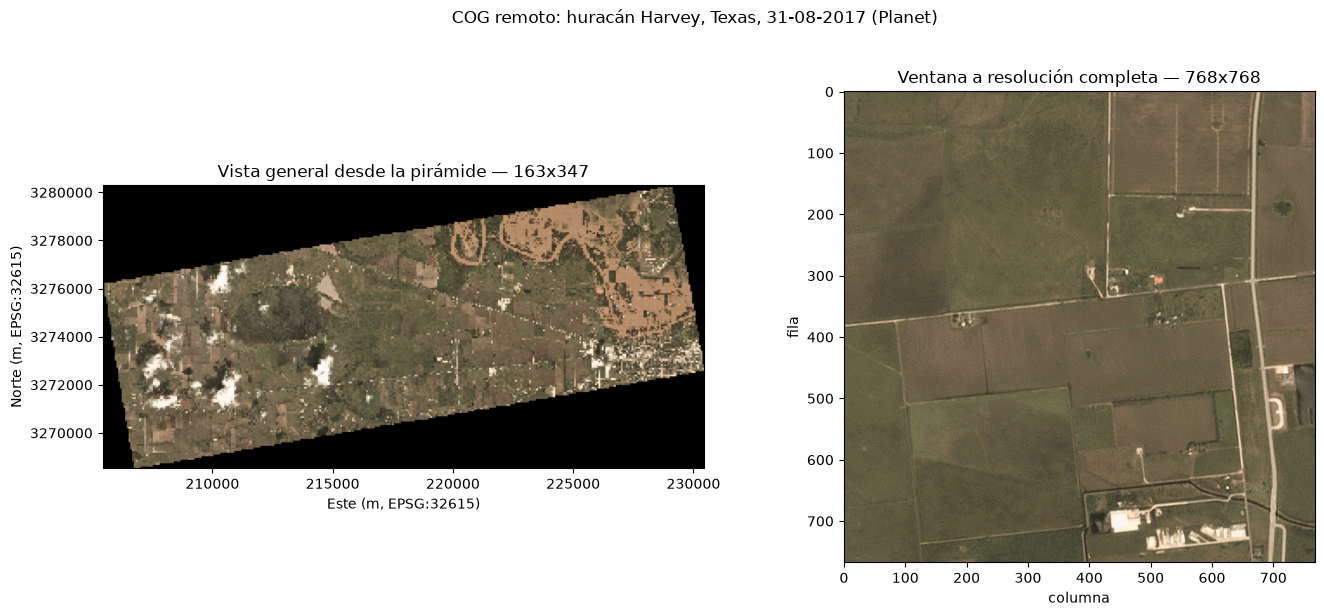

In [50]:
from rasterio.plot import reshape_as_image

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(reshape_as_image(vista), extent=extension_cog, origin="upper")
ax1.set_title(f"Vista general desde la pirámide — {vista.shape[1]}x{vista.shape[2]}")
ax1.set_xlabel("Este (m, EPSG:32615)")
ax1.set_ylabel("Norte (m, EPSG:32615)")
ax1.ticklabel_format(style="plain")

ax2.imshow(reshape_as_image(detalle))
ax2.set_title("Ventana a resolución completa — 768x768")
ax2.set_xlabel("columna")
ax2.set_ylabel("fila")

fig.suptitle("COG remoto: huracán Harvey, Texas, 31-08-2017 (Planet)", y=1.02)
plt.tight_layout()
plt.show()

Nada de esto descargó la imagen completa. Ese es el punto del COG: los datos se quedan en el servidor y el cliente pide lo que va a mostrar. Es la base de los catálogos STAC, de los visores web de imágenes satelitales y de los servicios de datos abiertos en la nube (Sentinel-2, Landsat y MODIS se publican hoy como COG).

Para verificar si un archivo cumple la especificación existe la herramienta `rio cogeo validate`, del paquete `rio-cogeo`.

## 13. NetCDF y HDF5: rasters multidimensionales

Un GeoTIFF guarda una malla 2D, eventualmente con varias bandas. Pero muchos datos ambientales tienen más dimensiones: una variable climática cambia en el tiempo; una variable atmosférica cambia además con la altura. Apilar eso en bandas de un GeoTIFF se vuelve inmanejable, porque las bandas no tienen etiquetas: la banda 178 no dice a qué fecha corresponde.

**NetCDF** y **HDF5** resuelven ese problema. Son contenedores *autodescritos*: guardan arreglos de N dimensiones junto con los nombres de esas dimensiones, los valores de cada coordenada y atributos de texto que documentan unidades, autor y procedencia. La relación entre ambos es de implementación: NetCDF-4 está construido sobre HDF5, mientras que NetCDF-3 —el formato clásico— tiene su propia estructura binaria.

Los formatos son los habituales en reanálisis climáticos, salidas de modelos numéricos y productos satelitales (MODIS, GPM, Sentinel-3).

### 13.1 Descargar un NetCDF

Se usa un extracto del reanálisis del NCEP: temperatura del aire en superficie sobre Norteamérica, cuatro veces al día durante 2013 y 2014.

A diferencia del COG, estos formatos no se leen bien por HTTP pedazo a pedazo: su estructura interna obliga a saltar de un lado a otro del archivo. Lo normal es descargar la copia local —como aquí— o acceder a través de un servidor OPeNDAP/THREDDS, que sirve los pedazos ya recortados.

In [ ]:
from urllib.request import urlretrieve


def descargar(url, destino):
    """Descarga la url solo si el archivo no existe ya en el disco."""
    if not destino.exists():
        urlretrieve(url, destino)
    return destino


url_nc = "https://github.com/pydata/xarray-data/raw/master/air_temperature.nc"

ruta_nc = descargar(url_nc, "air_temperature.nc")

print(f"Tamaño: {ruta_nc.stat().st_size / 1024**2:.2f} MB")

Tamaño: 7.39 MB


Los primeros bytes de un archivo delatan su formato, igual que la cabecera delataba al ASCII Grid. `CDF\x01` y `CDF\x02` corresponden a NetCDF clásico; `\x89HDF` identifica un contenedor HDF5, que es lo que hay dentro de un NetCDF-4.

In [52]:
def firma(ruta):
    with open(ruta, "rb") as f:
        inicio = f.read(4)
    if inicio.startswith(b"CDF"):
        return inicio, "NetCDF clásico (versión %d)" % inicio[3]
    if inicio == b"\x89HDF":
        return inicio, "HDF5 (posiblemente NetCDF-4)"
    return inicio, "otro formato"


print(ruta_nc.name, "->", firma(ruta_nc))

air_temperature.nc -> (b'CDF\x01', 'NetCDF clásico (versión 1)')


### 13.2 Abrir el NetCDF con xarray

`rasterio` puede leer estos archivos, pero la herramienta natural es **xarray**, que representa el contenido tal como está organizado: un `Dataset` con variables, dimensiones con nombre, coordenadas y atributos.

In [53]:
import xarray as xr

ds = xr.open_dataset(ruta_nc)
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [54]:
print("Dimensiones :", dict(ds.sizes))
print("Variables   :", list(ds.data_vars))
print("Coordenadas :", list(ds.coords))
print("\nAtributos globales:")
for clave, valor in ds.attrs.items():
    print(f"  {clave:<12}: {str(valor)[:70]}")

print("\nAtributos de la variable 'air':")
for clave, valor in ds["air"].attrs.items():
    print(f"  {clave:<12}: {valor}")

Dimensiones : {'time': 2920, 'lat': 25, 'lon': 53}
Variables   : ['air']
Coordenadas : ['lat', 'lon', 'time']

Atributos globales:
  Conventions : COARDS
  title       : 4x daily NMC reanalysis (1948)
  description : Data is from NMC initialized reanalysis
(4x/day).  These are the 0.995
  platform    : Model
  references  : http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanalysis.html

Atributos de la variable 'air':
  long_name   : 4xDaily Air temperature at sigma level 995
  units       : degK
  precision   : 2
  GRIB_id     : 11
  GRIB_name   : TMP
  var_desc    : Air temperature
  dataset     : NMC Reanalysis
  level_desc  : Surface
  statistic   : Individual Obs
  parent_stat : Other
  actual_range: [185.16 322.1 ]


Un cubo de 2920 × 25 × 53: 2920 instantes de tiempo sobre una malla de 25 filas por 53 columnas. La variable viene en kelvin, según su atributo `units`, y las coordenadas están explícitas: no hay que reconstruirlas a partir de un origen y un tamaño de celda como en el ASCII Grid.

La consecuencia práctica es que se puede **seleccionar por etiqueta** en lugar de por índice. Comparar las dos formas deja clara la diferencia con `numpy`.

In [55]:
aire = ds["air"] - 273.15        # kelvin -> grados Celsius
aire.attrs["units"] = "°C"

# por posición, como en numpy
print("Por índice  :", float(aire[0, 0, 0].values).__round__(2), "°C")

# por etiqueta, que es lo que xarray aporta
punto = aire.sel(time="2013-07-15T12:00:00", lat=40, lon=255, method="nearest")
print("Por etiqueta:", float(punto.values).__round__(2), "°C",
      "en", str(punto.time.values)[:16])

Por índice  : -31.95 °C
Por etiqueta: 14.95 °C en 2013-07-15T12:00


Las operaciones también se escriben con el nombre de la dimensión, no con el número del eje: `mean("time")` en lugar de `mean(axis=0)`. Es más legible y no depende del orden en que estén guardadas las dimensiones.

In [56]:
media_temporal = aire.mean("time")           # promedio de los dos años, celda a celda
serie_medellin = aire.sel(lat=25, lon=260, method="nearest")   # serie en un punto

print("Media temporal :", media_temporal.dims, media_temporal.shape)
print("Serie puntual  :", serie_medellin.dims, serie_medellin.shape)
print(f"\nTemperatura media del dominio: {float(aire.mean()):.1f} °C")

Media temporal : ('lat', 'lon') (25, 53)
Serie puntual  : ('time',) (2920,)

Temperatura media del dominio: 8.1 °C


### 13.3 Representar los datos

`xarray` trae su propio `.plot()`, que usa `matplotlib` por debajo y rotula los ejes con los nombres y unidades que vienen en el archivo.

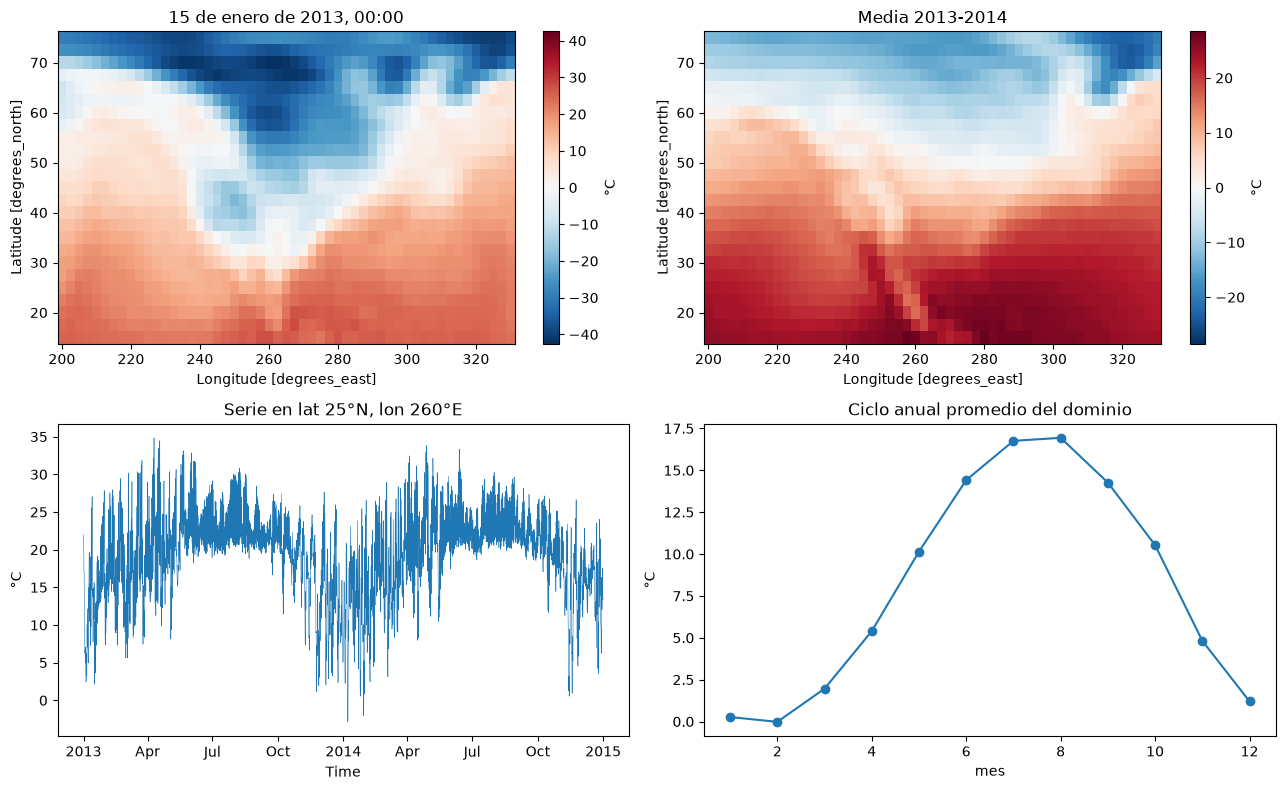

In [57]:
fig, ejes = plt.subplots(2, 2, figsize=(13, 8))

# un instante concreto
aire.sel(time="2013-01-15T00:00:00").plot(
    ax=ejes[0, 0], cmap="RdBu_r", cbar_kwargs={"label": "°C"})
ejes[0, 0].set_title("15 de enero de 2013, 00:00")

# promedio de los dos años
media_temporal.plot(ax=ejes[0, 1], cmap="RdBu_r", cbar_kwargs={"label": "°C"})
ejes[0, 1].set_title("Media 2013-2014")

# serie de tiempo en un punto
serie_medellin.plot(ax=ejes[1, 0], lw=0.4)
ejes[1, 0].set_title("Serie en lat 25°N, lon 260°E")
ejes[1, 0].set_ylabel("°C")

# ciclo anual promedio del dominio
aire.mean(["lat", "lon"]).groupby("time.month").mean().plot(
    ax=ejes[1, 1], marker="o")
ejes[1, 1].set_title("Ciclo anual promedio del dominio")
ejes[1, 1].set_ylabel("°C")
ejes[1, 1].set_xlabel("mes")

plt.tight_layout()
plt.show()

### 13.4 Un archivo HDF5 de verdad

El archivo anterior resultó ser NetCDF clásico. Para ver un contenedor HDF5 se descarga una salida del modelo oceánico ROMS, publicada como NetCDF-4.

In [58]:
url_roms = "https://github.com/pydata/xarray-data/raw/master/ROMS_example.nc"

ruta_roms = descargar(url_roms, DIR_SALIDA / "ROMS_example.nc")

print(ruta_roms.name, "->", firma(ruta_roms))
print(f"Tamaño: {ruta_roms.stat().st_size / 1024**2:.2f} MB")

ROMS_example.nc -> (b'\x89HDF', 'HDF5 (posiblemente NetCDF-4)')
Tamaño: 8.96 MB


GDAL —y por tanto `rasterio`— abre estos contenedores, pero como no son rasters simples, lo primero que reporta es la lista de **subdatasets**: una entrada por cada variable que pueda interpretarse como malla. La sintaxis `netcdf:archivo:variable` selecciona una de ellas.

Al abrirlo aparece una advertencia, `NotGeoreferencedWarning`, y conviene entenderla en lugar de silenciarla: estos archivos normalmente no traen una transformación afín ni un CRS al estilo GeoTIFF. Las coordenadas viven en variables propias —aquí `lon_rho` y `lat_rho`— y pueden ni siquiera formar una malla regular, como ocurre en las rejillas curvilíneas de los modelos oceánicos.

In [59]:
import warnings

with rasterio.open(ruta_roms) as src:
    print("Driver:", src.driver)
    print("Subdatasets:")
    for sd in src.subdatasets:
        print("  ", sd.replace(str(ruta_roms), ruta_roms.name))

Driver: netCDF
Subdatasets:
   netcdf:ROMS_example.nc:salt
   netcdf:ROMS_example.nc:zeta
   netcdf:ROMS_example.nc:lon_rho
   netcdf:ROMS_example.nc:h
   netcdf:ROMS_example.nc:lat_rho


C:\Users\edier\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [60]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")           # la advertencia ya quedó explicada
    with rasterio.open(f"netcdf:{ruta_roms}:zeta") as src:
        print("Variable      : zeta (elevación de la superficie del mar)")
        print("Dimensiones   :", f"{src.height} filas x {src.width} columnas")
        print("Bandas        :", src.count, "(cada banda es un instante de tiempo)")
        print("Tipo de dato  :", src.dtypes[0])
        print("CRS           :", src.crs)
        print("NODATA        :", src.nodata, "(el relleno de tierra firme)")
        print("Transformación:", src.transform)
        zeta = src.read(1, masked=True)

print(f"\nRango de la banda 1: {zeta.min():.3f} a {zeta.max():.3f} m")
print(f"Celdas de agua: {zeta.count():,} de {zeta.size:,}")

Variable      : zeta (elevación de la superficie del mar)
Dimensiones   : 191 filas x 371 columnas
Bandas        : 2 (cada banda es un instante de tiempo)
Tipo de dato  : float32
CRS           : None
NODATA        : 9.999999933815813e+36 (el relleno de tierra firme)
Transformación: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|

Rango de la banda 1: -0.296 a -0.031 m
Celdas de agua: 52,835 de 70,861


El valor de relleno es `1e+37`, y conviene pasarlo a `NaN` antes de graficar: aunque la máscara ya lo excluye de las estadísticas, `matplotlib` normaliza sobre los datos crudos y un valor tan grande desborda el cálculo de la escala de color.

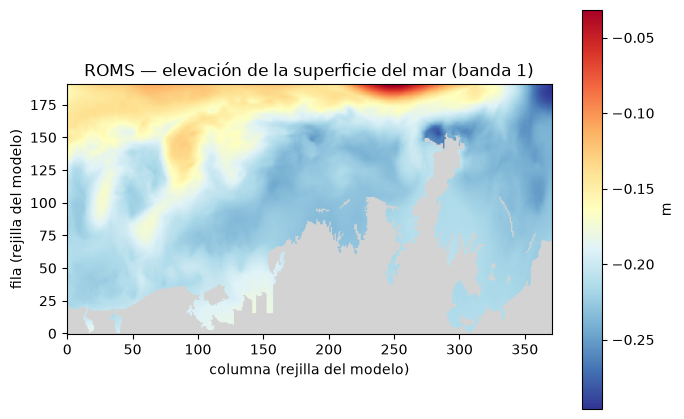

In [61]:
mapa_zeta = plt.get_cmap("RdYlBu_r").copy()
mapa_zeta.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(7, 5))
img = ax.imshow(zeta.filled(np.nan), cmap=mapa_zeta, origin="lower")
ax.set_title("ROMS — elevación de la superficie del mar (banda 1)")
ax.set_xlabel("columna (rejilla del modelo)")
ax.set_ylabel("fila (rejilla del modelo)")
fig.colorbar(img, ax=ax, shrink=0.85, label="m")
plt.tight_layout()
plt.show()

Los ejes son índices de la rejilla del modelo, no coordenadas: sin transformación afín no hay forma de ponerles metros o grados directamente. Para georreferenciarlo habría que usar las variables `lon_rho` y `lat_rho`, que dan la posición de cada celda una por una.

`xarray` también abre este archivo, pero necesita un motor capaz de leer HDF5 (`netcdf4` o `h5netcdf`), que no siempre viene instalado. Si hace falta: `conda install -c conda-forge netcdf4`.

### 13.5 De NetCDF a GeoTIFF

**rioxarray** conecta los dos mundos: agrega a los objetos de `xarray` un accesor `.rio` con las operaciones geoespaciales, incluida la escritura a GeoTIFF.

Antes de exportar hay que resolver un detalle típico de los datos climáticos: las longitudes vienen de 0° a 360°, y la mayoría de los SIG espera de -180° a 180°. Sin esa corrección, la capa aparecería en el hemisferio equivocado.

In [62]:
import rioxarray      # registra el accesor .rio en los objetos de xarray

print("Longitudes originales:", float(aire.lon.min()), "a", float(aire.lon.max()))

media = media_temporal.assign_coords(lon=(((media_temporal.lon + 180) % 360) - 180))
media = media.sortby("lon")

print("Longitudes corregidas:", float(media.lon.min()), "a", float(media.lon.max()))

Longitudes originales: 200.0 a 330.0
Longitudes corregidas: -160.0 a -30.0


In [63]:
ruta_nc_tif = DIR_SALIDA / "air_media_2013_2014.tif"

media = media.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
media = media.rio.write_crs("EPSG:4326")      # las coordenadas son grados geográficos
media.rio.to_raster(ruta_nc_tif)

with rasterio.open(ruta_nc_tif) as src:
    print("Archivo     :", ruta_nc_tif.name)
    print("Driver      :", src.driver)
    print("Dimensiones :", f"{src.height} x {src.width}")
    print("CRS         :", src.crs)
    print("Resolución  :", src.res, "grados")
    print("Extensión   :", src.bounds)

Archivo     : air_media_2013_2014.tif
Driver      : GTiff
Dimensiones : 25 x 53
CRS         : EPSG:4326
Resolución  : (2.5, 2.5) grados
Extensión   : BoundingBox(left=-161.25, bottom=13.75, right=-28.75, top=76.25)


El cubo de 2920 instantes quedó reducido a una malla 2D en un GeoTIFF georreferenciado, listo para abrirse en QGIS o combinarse con cualquier otra capa. El camino inverso también existe: `rioxarray.open_rasterio` lee un GeoTIFF como objeto de `xarray`.

In [64]:
ds.close()
print("Dataset cerrado.")

Dataset cerrado.


## 14. Resumen

- Un ASCII Grid es texto plano: una cabecera de seis líneas seguida de los valores. Esa cabecera —origen, tamaño de celda y `NODATA`— es lo que convierte una matriz de números en un dato espacial.
- La extensión no define el formato. `geologia.txt` es un ASCII Grid y GDAL lo abre como tal, porque identifica el formato por el contenido.
- El ASCII Grid no guarda el CRS. Si no hay un `.prj` al lado, el archivo tiene coordenadas pero no dice a qué sistema pertenecen: `rasterio` reporta `crs = None`.
- En un ASCII Grid la primera fila de datos es la del norte. Al escribir uno desde un arreglo propio hay que tenerlo en cuenta (`np.flipud`), porque un mapa invertido verticalmente no siempre salta a la vista.
- Leer con `masked=True` evita que los `-9999` contaminen las estadísticas. Una elevación media negativa es la señal típica de que esto se olvidó.
- Para graficar como mapa se necesitan `extent` y `origin`; sin ellos la figura muestra índices de celda, no coordenadas. Para datos categóricos conviene un `ListedColormap`, no una rampa continua.
- El sombreado del relieve se deriva del modelo de elevación en tres pasos: gradientes con `np.gradient`, pendiente y orientación, y la fórmula de iluminación. Es una representación, no una propiedad del terreno: cambiar el azimut del sol cambia lo que se percibe, y por convención se ilumina desde el noroeste para evitar la inversión del relieve.
- Antes de combinar dos rasters hay que verificar resolución, extensión y alineación. Si las mallas están corridas, se remuestrea con `nearest` para categóricas y `bilinear` o `cubic` para continuas.
- El GeoTIFF es el formato de trabajo: binario, comprimido, multibanda y con el CRS incorporado. Se puede abrir directamente desde una URL y leerse por ventanas o en versión decimada sin traer todo el archivo.
- Las bandas se numeran desde 1: `src.read()` trae todas, `src.read(1)` una sola, `src.read([4, 3, 2])` un subconjunto.
- Un COG es un GeoTIFF con teselas internas, pirámides internas y un orden que permite pedir por HTTP solo los bytes necesarios. Cualquier programa lo abre como un GeoTIFF normal; la diferencia está en cuánto hay que descargar para usarlo.
- NetCDF y HDF5 guardan cubos de N dimensiones con coordenadas y atributos explícitos. `xarray` los lee tal como están organizados y permite seleccionar por etiqueta (`sel(time=...)`) y operar por nombre de dimensión (`mean("time")`).
- Estos contenedores rara vez traen un CRS al estilo GeoTIFF: las coordenadas viven en variables. `rioxarray` añade el accesor `.rio` para asignar el CRS y exportar a GeoTIFF.
